# Phân tích khám phá dữ liệu (EDA)
Bộ dữ liệu: **Bike Sharing Dataset** — file `hour.csv`

## Giới thiệu bộ dữ liệu Bike Sharing

Bộ dữ liệu **Bike Sharing Dataset** ghi nhận thông tin thuê xe đạp tự động từ hệ thống Capital Bikeshare, Washington D.C., Mỹ trong hai năm 2011-2012. Dữ liệu được tổng hợp theo giờ và ngày, có tích hợp thêm thông tin thời tiết và mùa.

**Thông tin chi tiết:**
* **Tập dữ liệu sử dụng:** `hour.csv` với 17.379 mẫu.
* **Biến mục tiêu (Target):** `cnt` (tổng số lượng xe đạp được thuê).
* **Các đặc trưng (Features):** Bao gồm các biến về thời gian (giờ, ngày, tháng, mùa, ngày lễ) và các chỉ số thời tiết (nhiệt độ `temp`, độ ẩm `hum`, tốc độ gió `windspeed`).

In [90]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Xác định ROOT: thư mục chứa 'data/'
try:
    ROOT = Path(__file__).resolve().parent.parent
except NameError:
    cwd = Path.cwd()
    for candidate in [cwd, cwd.parent, cwd.parent.parent]:
        if (candidate / "data").exists():
            ROOT = candidate
            break
    else:
        raise FileNotFoundError(f"Không tìm thấy thư mục 'data/' từ {cwd}")

DATA_DIR = ROOT / "data"
IMGS_DIR = Path(Path.cwd()) / "imgs"
IMGS_DIR.mkdir(exist_ok=True)

print(f"ROOT     : {ROOT}")
print(f"DATA_DIR : {DATA_DIR}")
print(f"IMGS_DIR : {IMGS_DIR}")
assert (DATA_DIR / "hour.csv").exists(), f"Không tìm thấy {DATA_DIR / 'hour.csv'}"

plt.rcParams["figure.dpi"] = 120

ROOT     : /home/lesliu/Documents/school/25_26_Semester_2/intro2ml/lab1
DATA_DIR : /home/lesliu/Documents/school/25_26_Semester_2/intro2ml/lab1/data
IMGS_DIR : /home/lesliu/Documents/school/25_26_Semester_2/intro2ml/lab1/code/Part1_Regression/imgs


## 1. Đọc và tổng quan dữ liệu

In [91]:
df = pd.read_csv(DATA_DIR / "hour.csv")
print(f"Kích thước: {df.shape[0]} mẫu, {df.shape[1]} cột")
df.head()

Kích thước: 17379 mẫu, 17 cột


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


Kiểm tra giá trị thiếu:

In [93]:
missing = df.isnull().sum()
print("Số giá trị thiếu theo cột:")
print(missing[missing > 0] if missing.any() else "Không có giá trị thiếu.")

Số giá trị thiếu theo cột:
Không có giá trị thiếu.


## 1.5. Các cột không cần thiết
Dựa vào mô tả của tác giả về bộ dữ liệu, ta sẽ không sử dụng các cột `casual` và `registered` vì chúng chỉ là thành phần của biến mục tiêu `cnt` và không có ý nghĩa dự đoán trong thực tế. Do đó, nếu đưa các cột này vào mô hình, mô hình sẽ vô tình sử dụng thông tin của biến mục tiêu để dự đoán chính nó. Điều này gây ra **data leakage**, khiến kết quả đánh giá mô hình không còn phản ánh đúng khả năng dự đoán trong thực tế.

Ngoài ra, cột `instant` chỉ đóng vai trò là chỉ số dòng (index) của dữ liệu và không mang thông tin có giá trị cho việc dự đoán.

Cột `dteday` biểu diễn ngày tháng dưới dạng timestamp, tuy nhiên các đặc trưng thời gian quan trọng như yr, mnth, hr, weekday và season đã được tách sẵn trong bộ dữ liệu. Vì vậy, việc giữ lại dteday là không cần thiết cho mô hình hồi quy.

## 2. Thống kê mô tả

In [94]:
FEATURES = ["temp", "atemp", "hum", "windspeed",
            "season", "yr", "mnth", "hr",
            "holiday", "weekday", "workingday", "weathersit"]
TARGET = "cnt"

stat = df[FEATURES + [TARGET]].describe().T[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
]
stat.columns = ["Trung bình", "Độ lệch chuẩn", "Min", "Q1", "Trung vị", "Q3", "Max"]
stat.round(4)

,Trung bình,Độ lệch chuẩn,Min,Q1,Trung vị,Q3,Max
temp,0.4970,0.1926,0.02,0.3400,0.5000,0.6600,1.0000
atemp,0.4758,0.1719,0.00,0.3333,0.4848,0.6212,1.0000
hum,0.6272,0.1929,0.00,0.4800,0.6300,0.7800,1.0000
windspeed,0.1901,0.1223,0.00,0.1045,0.1940,0.2537,0.8507
season,2.5016,1.1069,1.00,2.0000,3.0000,3.0000,4.0000
yr,0.5026,0.5000,0.00,0.0000,1.0000,1.0000,1.0000
mnth,6.5378,3.4388,1.00,4.0000,7.0000,10.0000,12.0000
hr,11.5468,6.9144,0.00,6.0000,12.0000,18.0000,23.0000
holiday,0.0288,0.1672,0.00,0.0000,0.0000,0.0000,1.0000
weekday,3.0037,2.0058,0.00,1.0000,3.0000,5.0000,6.0000


## 3. Phân bố biến mục tiêu `cnt`

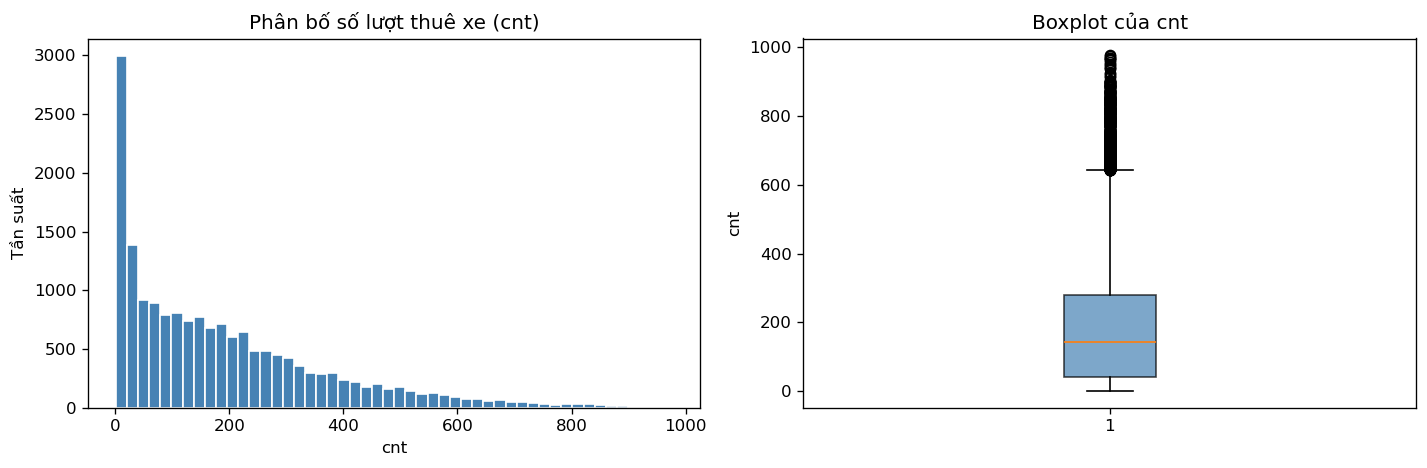

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df[TARGET], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Phân bố số lượt thuê xe (cnt)")
axes[0].set_xlabel("cnt")
axes[0].set_ylabel("Tần suất")

# Boxplot
axes[1].boxplot(df[TARGET], vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.7))
axes[1].set_title("Boxplot của cnt")
axes[1].set_ylabel("cnt")

plt.tight_layout()
plt.savefig(IMGS_DIR / "cnt_distribution.png")
plt.show()

**Nhận xét**

- Histogram cho thấy phân bố `cnt` **lệch phải mạnh**: đỉnh ở bin đầu (cnt thấp ~0–20) rồi giảm dần, đuôi kéo dài tới ~977.  
- Boxplot: trung vị = 142, Q1 = 40, Q3 = 281 — khoảng IQR = 241, trong khi trung bình = 189 >> trung vị.  
- Phần lớn giờ trong ngày có dưới 200 lượt thuê; chỉ một thiểu số giờ cao điểm đạt trên 600.

## 4. Ma trận tương quan

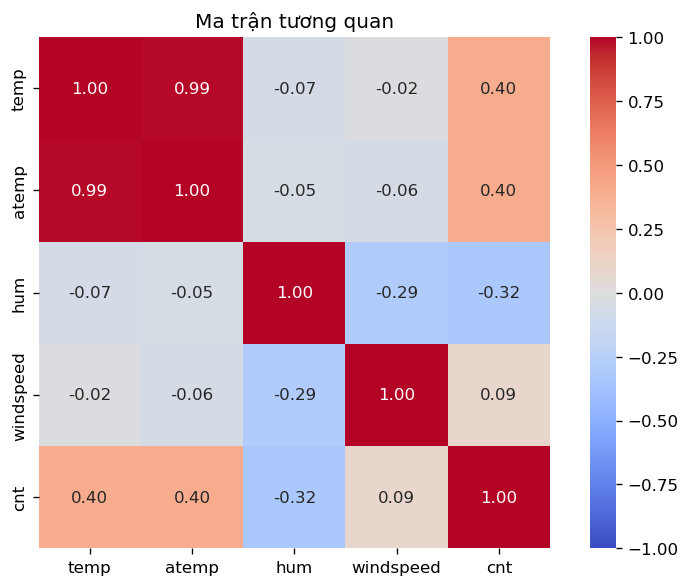

In [96]:
num_cols = ["temp", "atemp", "hum", "windspeed", TARGET]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Ma trận tương quan")
plt.tight_layout()
plt.savefig(IMGS_DIR / "correlation_matrix.png")
plt.show()

**Nhận xét**

- `temp` và `atemp` gần như đồng nhất (r = 0.99) → **đa cộng tuyến cao**, nên chọn một trong hai khi xây dựng mô hình.
- Cả `temp` và `atemp` đều có tương quan dương vừa phải với `cnt` (r = 0.40).
- `hum` có tương quan âm vừa phải với `cnt` (r = −0.32): độ ẩm cao làm giảm nhu cầu thuê xe.
- `windspeed` gần như không có tương quan tuyến tính với `cnt` (r = 0.09).

## 5. Scatter: `cnt` và các biến thời tiết

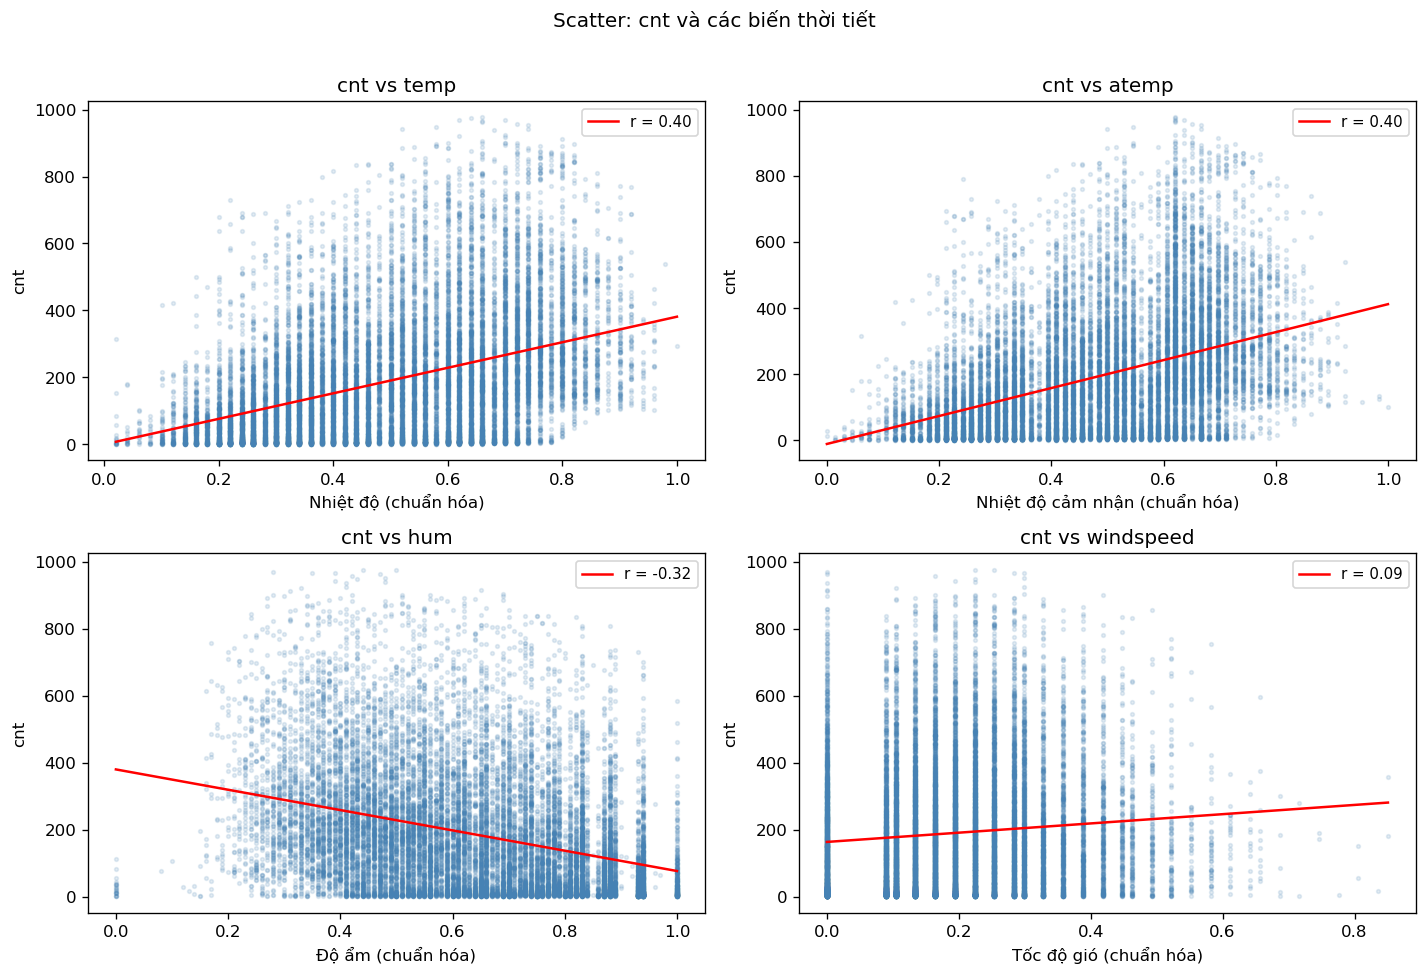

In [97]:
weather_vars = ["temp", "atemp", "hum", "windspeed"]
labels = {
    "temp": "Nhiệt độ (chuẩn hóa)",
    "atemp": "Nhiệt độ cảm nhận (chuẩn hóa)",
    "hum": "Độ ẩm (chuẩn hóa)",
    "windspeed": "Tốc độ gió (chuẩn hóa)",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, var in zip(axes.flat, weather_vars):
    ax.scatter(df[var], df[TARGET], alpha=0.15, s=5, color="steelblue")
    m, b, r, *_ = stats.linregress(df[var], df[TARGET])
    x_line = np.linspace(df[var].min(), df[var].max(), 100)
    ax.plot(x_line, m * x_line + b, color="red", linewidth=1.5, label=f"r = {r:.2f}")
    ax.set_xlabel(labels[var])
    ax.set_ylabel("cnt")
    ax.set_title(f"cnt vs {var}")
    ax.legend(fontsize=9)

plt.suptitle("Scatter: cnt và các biến thời tiết", y=1.01)
plt.tight_layout()
plt.savefig(IMGS_DIR / "scatter_weather_cnt.png", bbox_inches="tight")
plt.show()

**Nhận xét**

- `temp` và `atemp` (r = 0.40): xu hướng tăng rõ nhưng scatter rất rộng → quan hệ có thể phi tuyến, nhiều yếu tố khác cùng tác động.
- `hum` (r = −0.32): khi độ ẩm vượt ~0.8, `cnt` giảm mạnh và đột ngột — ảnh hưởng rõ hơn ở ngưỡng cao.
- `windspeed` (r = 0.09): dữ liệu dày đặc ở vùng tốc độ gió thấp (< 0.3), hầu như không có quan hệ tuyến tính đáng kể với `cnt`.

## 6. Barplot: `cnt` trung bình theo các biến phân loại / thời gian

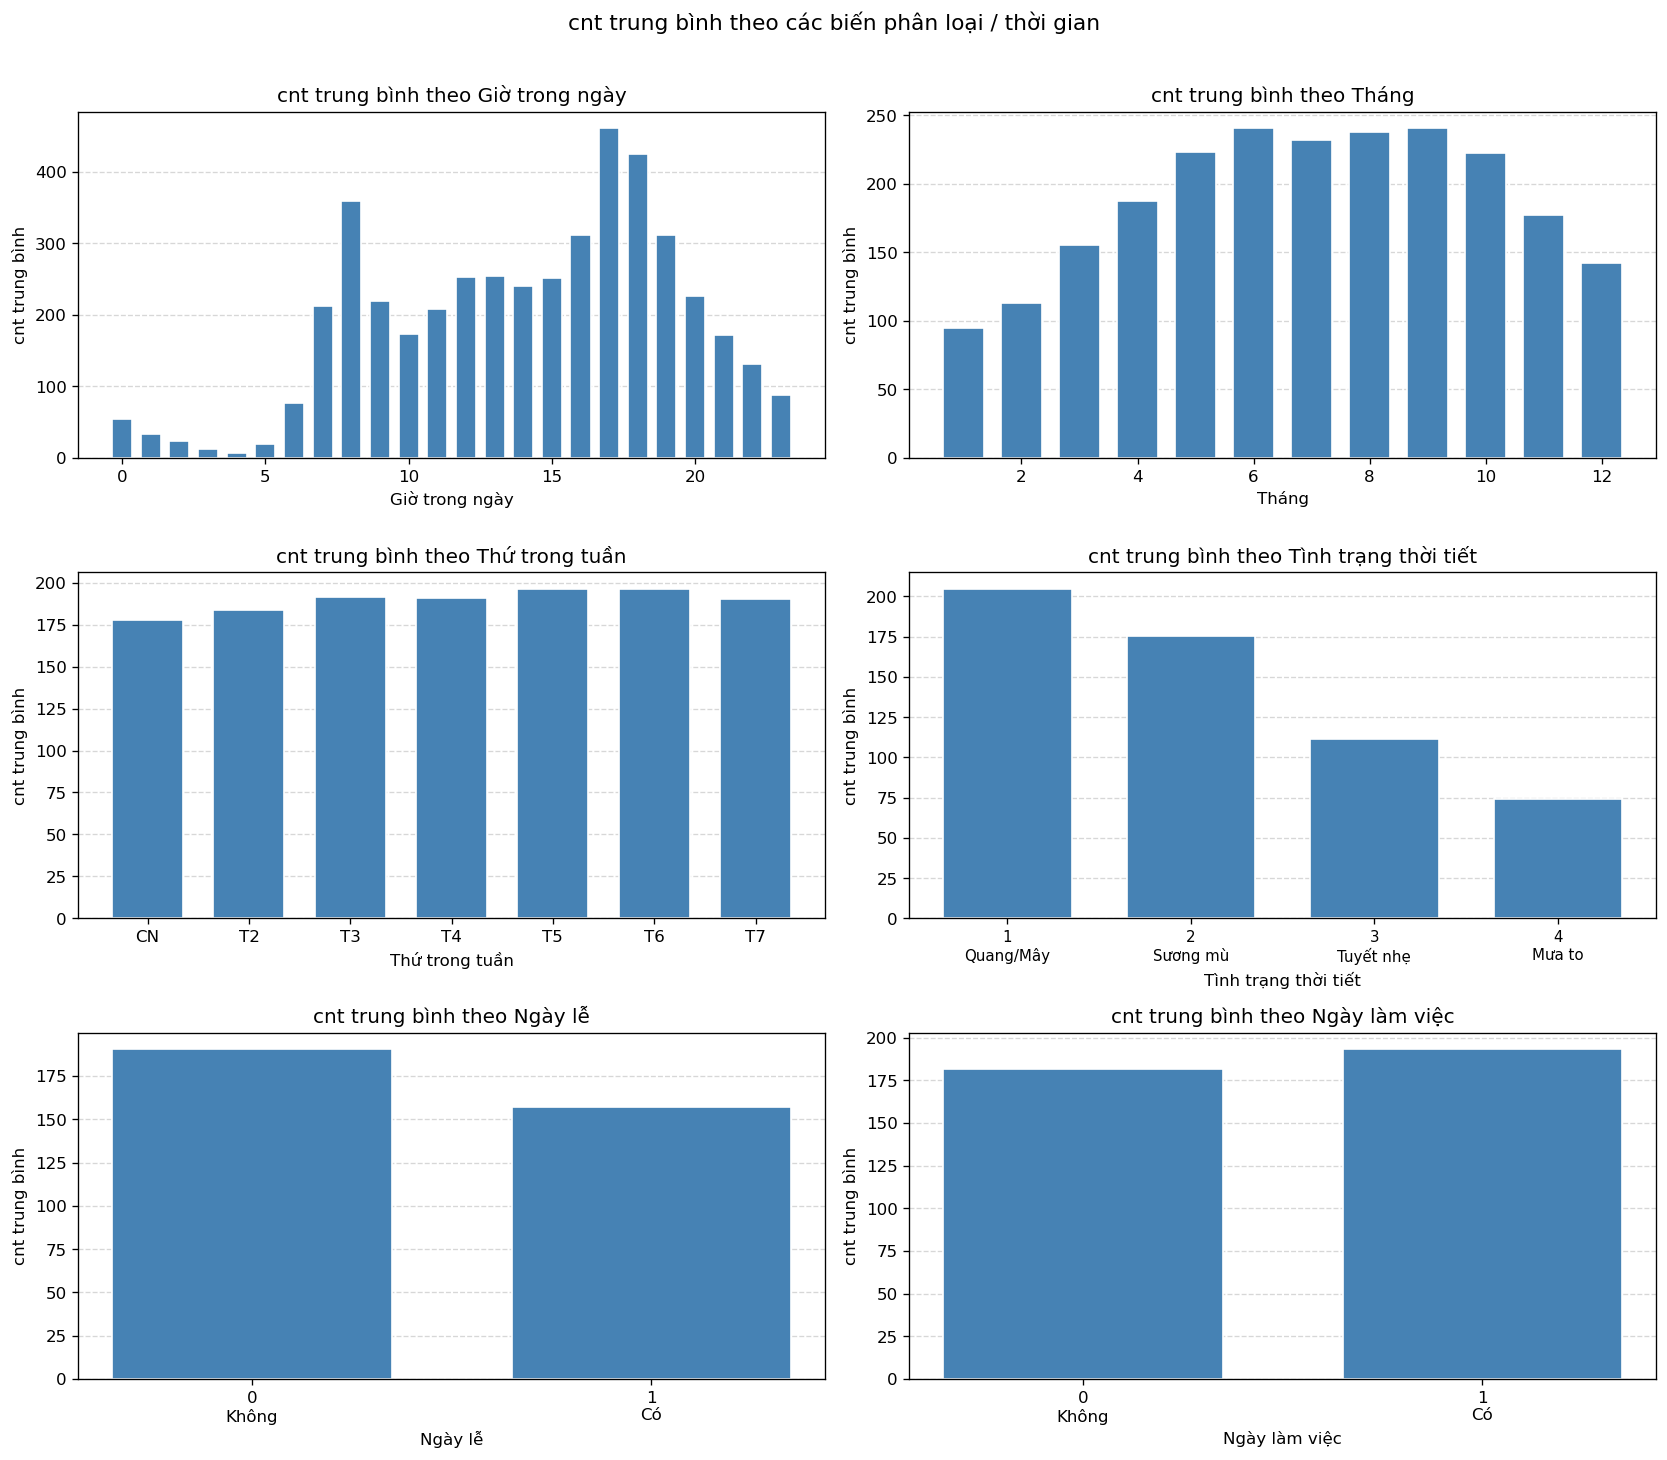

In [98]:
cat_vars = {
    "hr":         "Giờ trong ngày",
    "mnth":       "Tháng",
    "weekday":    "Thứ trong tuần",
    "weathersit": "Tình trạng thời tiết",
    "holiday":    "Ngày lễ",
    "workingday": "Ngày làm việc",
}

weekday_labels  = ["CN", "T2", "T3", "T4", "T5", "T6", "T7"]
weather_labels  = ["1\nQuang/Mây", "2\nSương mù", "3\nTuyết nhẹ", "4\nMưa to"]
binary_labels   = {
    "holiday":    ["0\nKhông", "1\nCó"],
    "workingday": ["0\nKhông", "1\nCó"],
}

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for ax, (var, title) in zip(axes.flat, cat_vars.items()):
    group = df.groupby(var)[TARGET].mean()
    bars = ax.bar(group.index, group.values, color="steelblue", edgecolor="white", width=0.7)

    # Tuỳ chỉnh nhãn trục x
    if var == "weekday":
        ax.set_xticks(range(7))
        ax.set_xticklabels(weekday_labels)
    elif var == "weathersit":
        ax.set_xticks([1, 2, 3, 4])
        ax.set_xticklabels(weather_labels, fontsize=9)
    elif var in binary_labels:
        ax.set_xticks([0, 1])
        ax.set_xticklabels(binary_labels[var])

    ax.set_title(f"cnt trung bình theo {title}")
    ax.set_xlabel(title)
    ax.set_ylabel("cnt trung bình")
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

plt.suptitle("cnt trung bình theo các biến phân loại / thời gian", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(IMGS_DIR / "cnt_by_categorical.png", bbox_inches="tight")
plt.show()

**Nhận xét**

- **`hr` (Giờ trong ngày):** Phân bố hai đỉnh rõ rệt — đỉnh buổi sáng lúc 8h (~350) và đỉnh buổi chiều 17–18h (~460). Đây là hành vi commute điển hình. Từ 0–5h sáng gần như không có thuê xe (<60). `hr` là biến phân loại có ảnh hưởng lớn nhất đến `cnt`.

- **`mnth` (Tháng):** Nhu cầu tăng từ tháng 1 (~95) đến đỉnh tháng 6–10 (~230–245), sau đó giảm dần. Phản ánh rõ yếu tố mùa — mùa đông lạnh ở Washington D.C. làm giảm nhu cầu đáng kể.

- **`weekday` (Thứ trong tuần):** Chênh lệch rất nhỏ giữa các ngày (~175–200). Chủ nhật thấp nhất (~175), các ngày trong tuần cao hơn một chút — xe đạp được sử dụng cả cho commute lẫn giải trí.

- **`weathersit` (Tình trạng thời tiết):** Giảm đơn điệu rõ rệt theo mức độ xấu của thời tiết: Quang/Mây (~205) → Sương mù (~172) → Tuyết nhẹ (~112) → Mưa to (~70). Mưa to làm giảm hơn **65%** so với trời quang — tác động mạnh nhất trong nhóm biến phân loại.

- **`holiday` (Ngày lễ):** Ngày lễ thấp hơn ngày thường (~157 so với ~185, giảm ~15%) do mất lưu lượng commute trong khi người dùng giải trí không bù đắp đủ.

- **`workingday` (Ngày làm việc):** Cao hơn nhẹ so với ngày nghỉ (~192 so với ~178, ~8%) — nhất quán với quan sát từ `holiday`.

## Phát hiện ngoại lai

In [99]:
# Phương pháp IQR
Q1 = df[TARGET].quantile(0.25)
Q3 = df[TARGET].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers_iqr = df[(df[TARGET] < lower) | (df[TARGET] > upper)]

print(f"IQR  — ngưỡng: [{lower:.1f}, {upper:.1f}]")
print(f"  Số ngoại lai: {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.2f}%)")

# Phương pháp Z-score
z = np.abs(stats.zscore(df[TARGET]))
outliers_z = df[z > 3]
print(f"\nZ-score (|z| > 3)")
print(f"  Số ngoại lai: {len(outliers_z)} ({len(outliers_z)/len(df)*100:.2f}%)")

IQR  — ngưỡng: [-321.5, 642.5]
  Số ngoại lai: 505 (2.91%)

Z-score (|z| > 3)
  Số ngoại lai: 244 (1.40%)


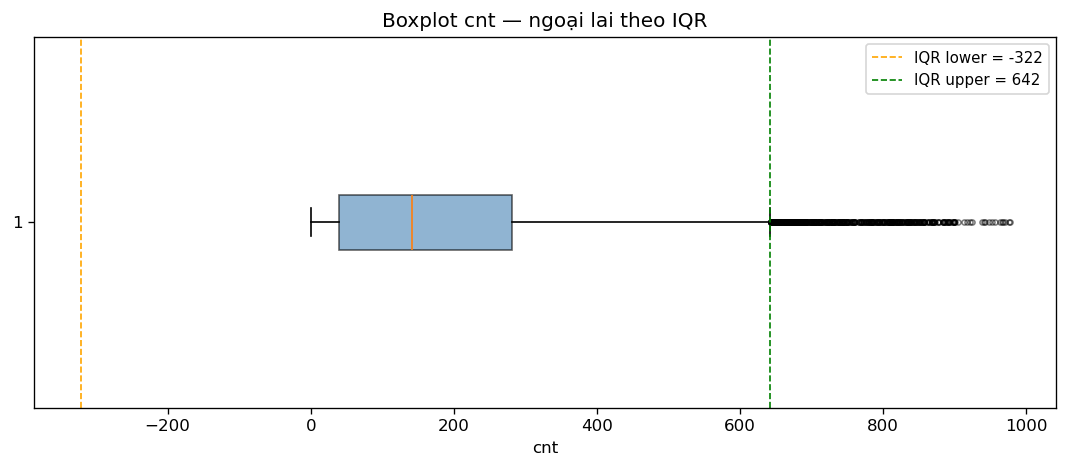

In [100]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(df[TARGET], vert=False, patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.6),
           flierprops=dict(marker="o", markersize=3, color="red", alpha=0.5))
ax.axvline(lower, color="orange", linestyle="--", linewidth=1, label=f"IQR lower = {lower:.0f}")
ax.axvline(upper, color="green",  linestyle="--", linewidth=1, label=f"IQR upper = {upper:.0f}")
ax.set_title("Boxplot cnt — ngoại lai theo IQR")
ax.set_xlabel("cnt")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(IMGS_DIR / "outliers_boxplot.png")
plt.show()

**Nhận xét**

- IQR: ngưỡng dưới = −322 (không có ý nghĩa vì `cnt` ≥ 1 → không có ngoại lai phía dưới), ngưỡng trên = 642 → **505 điểm (2.91%)** vượt ngưỡng.
- Z-score (|z| > 3): bảo thủ hơn, chỉ **244 điểm (1.40%)**.
- Các ngoại lai nằm hoàn toàn ở đuôi phải (cnt > 642), trải đến ~977 — đây là giờ cao điểm thực tế, dữ liệu hợp lệ, **không nên loại bỏ**.
- IQR cho tỉ lệ cao hơn thực tế do phân bố lệch phải làm kéo rộng khoảng tứ phân vị.